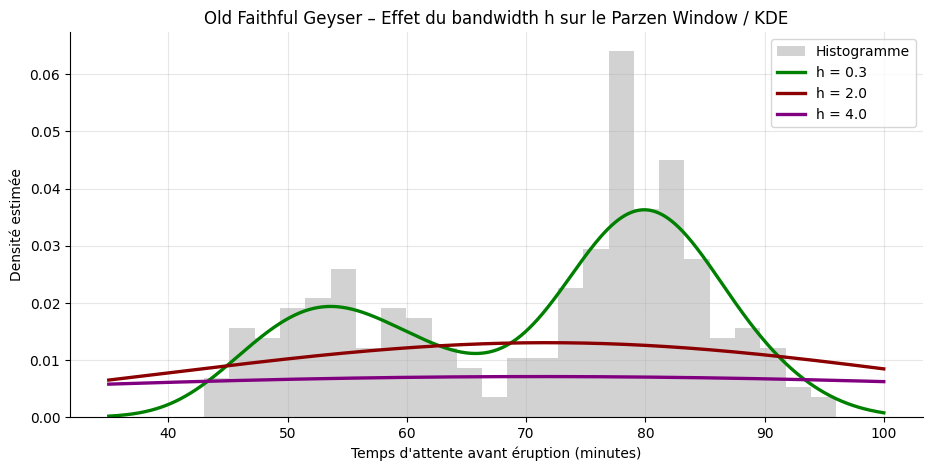

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Chargement du dataset (disponible dans seaborn)
data = sns.load_dataset("geyser")["waiting"]   # temps d'attente avant éruption (minutes)

# KDE avec différents bandwidths
plt.figure(figsize=(11, 5))

# Histogramme de référence
plt.hist(data, bins=25, density=True, alpha=0.35, color='gray', label='Histogramme')

x = np.linspace(35, 100, 800)

for bw, label, color in [
    (0.3,  "h = 0.3",   "green"),
    (2.0,  "h = 2.0",       "darkred"),
    (4.0,  "h = 4.0", "purple")
]:
    kde = gaussian_kde(data, bw_method=lambda x: bw)
    plt.plot(x, kde(x), lw=2.4, label=label, color=color)

plt.title("Old Faithful Geyser – Effet du bandwidth h sur le Parzen Window / KDE")
plt.xlabel("Temps d'attente avant éruption (minutes)")
plt.ylabel("Densité estimée")
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.show()

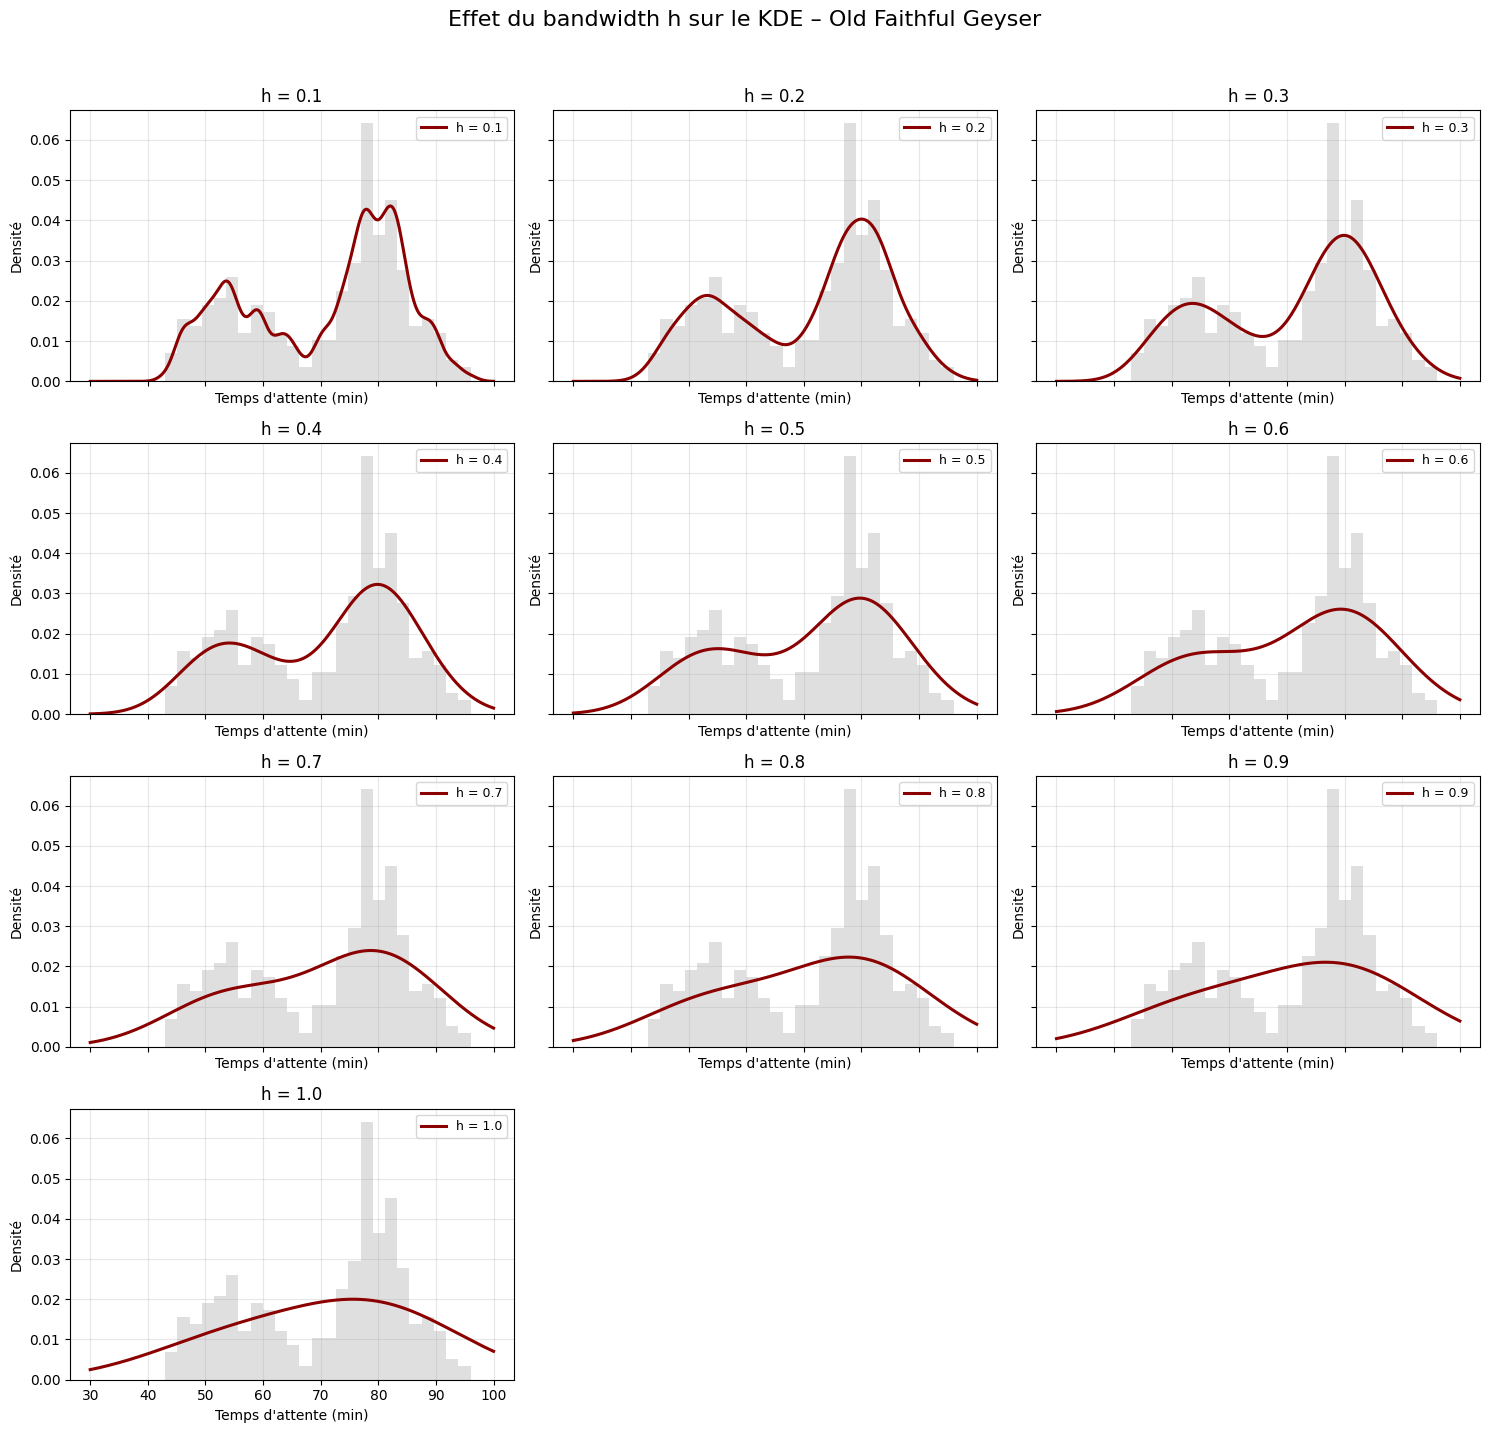

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Chargement des données
data = sns.load_dataset("geyser")["waiting"].to_numpy()

x_grid = np.linspace(30, 100, 1000)

h_values = np.arange(0.1, 1.01, 0.1)   

n_plots = len(h_values)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols  

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3.5 * nrows),
                         sharex=True, sharey=True)
axes = axes.flatten()  

for ax in axes:
    ax.hist(data, bins=25, density=True, alpha=0.25, color='gray', edgecolor='none')

# Pour chaque h
for i, h in enumerate(h_values):
    ax = axes[i]
    
    # Estimation KDE
    kde = gaussian_kde(data, bw_method=lambda x: h)
    density = kde(x_grid)
    
    ax.plot(x_grid, density, color='darkred', lw=2.2, label=f'h = {h:.1f}')
    
    ax.set_title(f'h = {h:.1f}', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Temps d'attente (min)")
    ax.set_ylabel("Densité")

# Supprime les axes vides s'il y en a
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Effet du bandwidth h sur le KDE – Old Faithful Geyser", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()